<a href="https://colab.research.google.com/github/luvvvv67/IPM06171-ITA-PROJECTS/blob/main/ITA_ArnavVerma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Generate a synthetic dataset of 10,000 rows with features like AccessFrequency and PurchaseHistory to predict Target_Surge. Perform initial data visualization, scale the features, and implement K-Means clustering to identify three "Behavioural Archetypes." Train and compare a baseline Random Forest model against a Hybrid Random Forest model (incorporating cluster IDs), evaluating both with confusion matrices. Finally, create business-oriented visualizations including a feature importance chart and a precision comparison to demonstrate how behavioral insights improve infrastructure optimization.

## Synthetic Data Generation and Initial Visualization

### Subtask:
Generate a 10,000-row synthetic dataset and visualize the relationships between key features.


**Reasoning**:
I will import the necessary libraries and generate a synthetic dataset with 10,000 rows including features like AccessFrequency, PurchaseHistory, and a binary target variable Target_Surge.



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_rows = 10000
access_frequency = np.random.poisson(lam=10, size=n_rows)
purchase_history = np.random.uniform(0, 500, size=n_rows)

# Simulate a target variable based on features with some noise
# Higher frequency and history increases probability of 'Target_Surge'
logit = -3 + 0.1 * access_frequency + 0.005 * purchase_history + np.random.normal(0, 0.5, size=n_rows)
prob = 1 / (1 + np.exp(-logit))
target_surge = (prob > 0.5).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'AccessFrequency': access_frequency,
    'PurchaseHistory': purchase_history,
    'Target_Surge': target_surge
})

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (10000, 3)
   AccessFrequency  PurchaseHistory  Target_Surge
0               12       463.876086             1
1                6       384.665294             0
2               11       415.720890             1
3               14        66.549134             0
4                7       395.923346             0


**Reasoning**:
With the dataset successfully generated, I will now create visualizations to explore the relationships and distributions of 'AccessFrequency' and 'PurchaseHistory' with respect to the 'Target_Surge' variable, as requested in the subtask instructions.



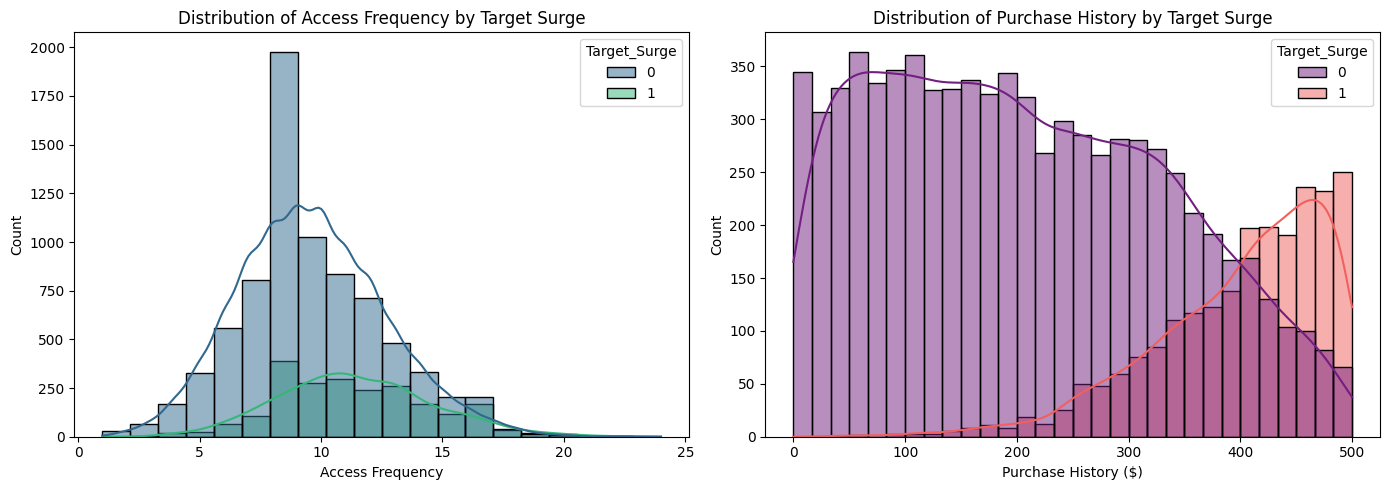

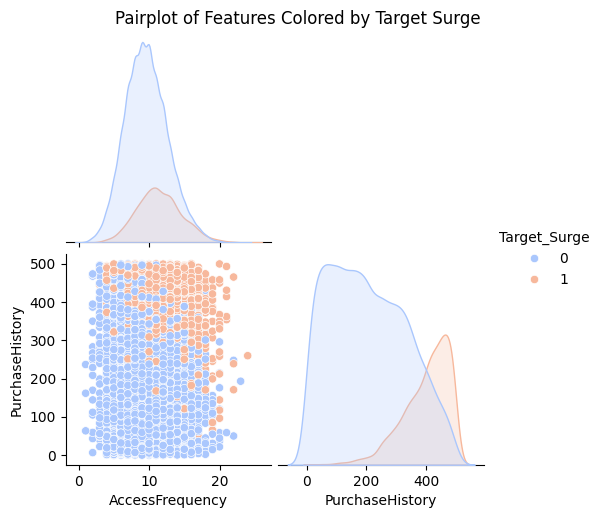

In [ ]:
plt.figure(figsize=(14, 5))

# Distribution of AccessFrequency by Target_Surge
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='AccessFrequency', hue='Target_Surge', kde=True, bins=20, palette='viridis')
plt.title('Distribution of Access Frequency by Target Surge')
plt.xlabel('Access Frequency')
plt.ylabel('Count')

# Distribution of PurchaseHistory by Target_Surge
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='PurchaseHistory', hue='Target_Surge', kde=True, bins=30, palette='magma')
plt.title('Distribution of Purchase History by Target Surge')
plt.xlabel('Purchase History ($)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Pairplot to see correlations
sns.pairplot(df, hue='Target_Surge', corner=True, palette='coolwarm')
plt.suptitle('Pairplot of Features Colored by Target Surge', y=1.02)
plt.show()

## Data Preprocessing and Feature Scaling

### Subtask:
Scale the numerical features to prepare the data for K-Means clustering and machine learning modeling.


**Reasoning**:
I will scale the numerical features 'AccessFrequency' and 'PurchaseHistory' using StandardScaler and visualize the results to ensure they are properly normalized for subsequent clustering.



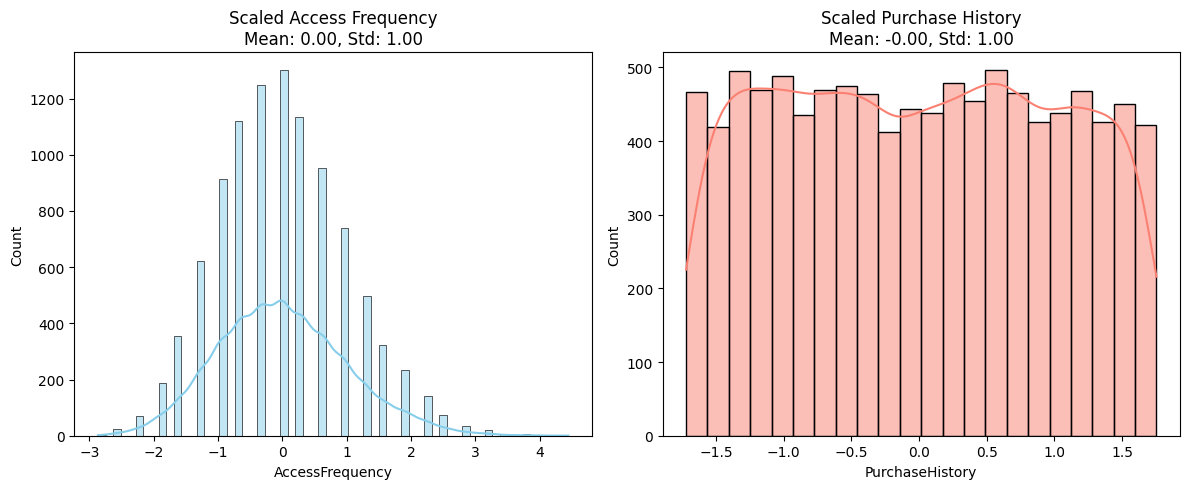

Summary Statistics of Scaled Data:
       AccessFrequency  PurchaseHistory
count         10000.00         10000.00
mean              0.00            -0.00
std               1.00             1.00
min              -2.87            -1.72
25%              -0.64            -0.87
50%              -0.01             0.01
75%               0.63             0.85
max               4.45             1.75


In [ ]:
from sklearn.preprocessing import StandardScaler

# Define numerical features to scale
num_features = ['AccessFrequency', 'PurchaseHistory']

# Instantiate and fit the scaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[num_features]), columns=num_features)

# Verification visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_scaled['AccessFrequency'], kde=True, color='skyblue')
plt.title(f'Scaled Access Frequency\nMean: {df_scaled["AccessFrequency"].mean():.2f}, Std: {df_scaled["AccessFrequency"].std():.2f}')

plt.subplot(1, 2, 2)
sns.histplot(df_scaled['PurchaseHistory'], kde=True, color='salmon')
plt.title(f'Scaled Purchase History\nMean: {df_scaled["PurchaseHistory"].mean():.2f}, Std: {df_scaled["PurchaseHistory"].std():.2f}')

plt.tight_layout()
plt.show()

print("Summary Statistics of Scaled Data:")
print(df_scaled.describe().round(2))

## K-Means Clustering and Cluster Visualization

### Subtask:
Implement K-Means to identify 3 'Behavioural Archetypes' and visualize the resulting segments.


**Reasoning**:
I will implement K-Means clustering with 3 clusters on the scaled data, assign the resulting cluster IDs back to the original dataframe, and visualize the segments to identify the 'Behavioural Archetypes'.



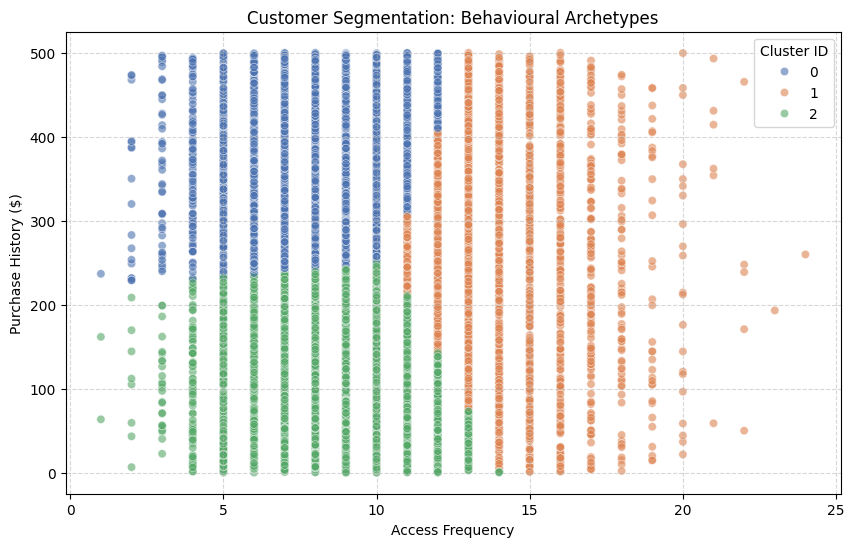

Cluster counts:
Cluster_ID
2    3749
0    3582
1    2669
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans

# 1 & 2. Instantiate KMeans with 3 clusters and a fixed random state
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

# 3. Fit and predict cluster assignments using the scaled data
clusters = kmeans.fit_predict(df_scaled)

# 4. Add Cluster_ID to the original dataframe
df['Cluster_ID'] = clusters

# 5, 6 & 7. Create a scatter plot to visualize the segments
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='AccessFrequency',
    y='PurchaseHistory',
    hue='Cluster_ID',
    palette='deep',
    alpha=0.6
)

plt.title('Customer Segmentation: Behavioural Archetypes')
plt.xlabel('Access Frequency')
plt.ylabel('Purchase History ($)')
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Cluster counts:")
print(df['Cluster_ID'].value_counts())

## Comparative Random Forest Modeling

### Subtask:
Train and evaluate a Baseline Random Forest model and a Hybrid Random Forest model (including cluster IDs) to compare performance.


**Reasoning**:
I will split the data into baseline and hybrid feature sets, train two Random Forest models, and visualize their performance using side-by-side confusion matrices as instructed.



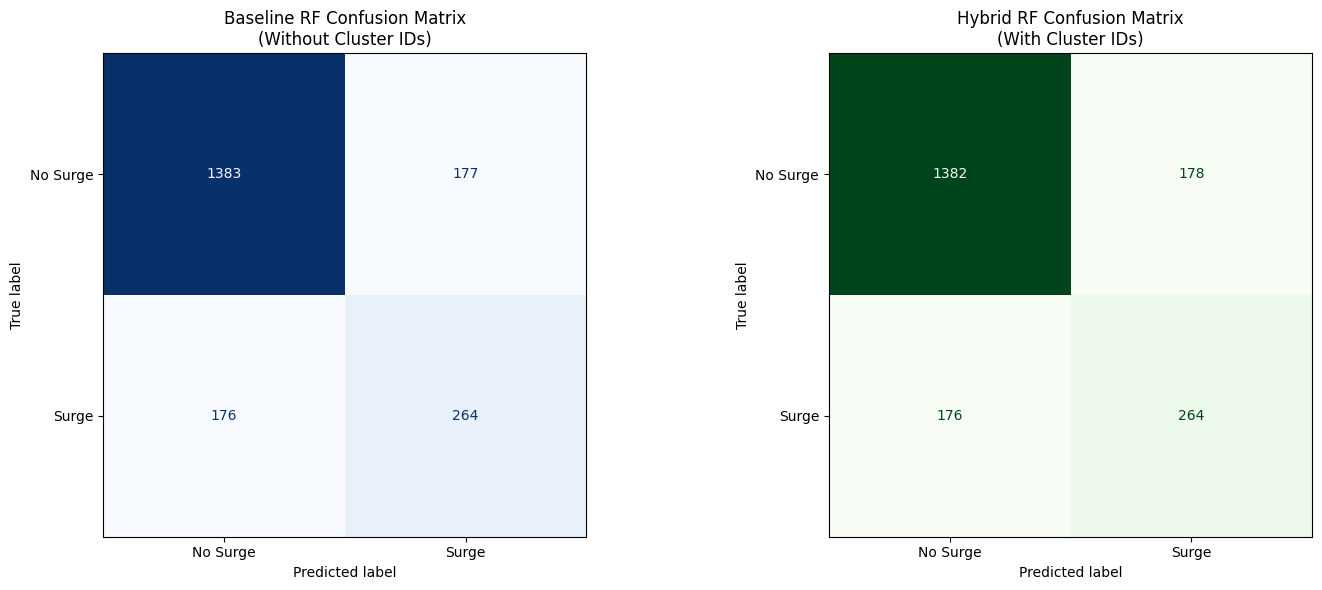

--- Baseline Model Report ---
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1560
           1       0.60      0.60      0.60       440

    accuracy                           0.82      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.82      0.82      0.82      2000


--- Hybrid Model Report ---
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1560
           1       0.60      0.60      0.60       440

    accuracy                           0.82      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.82      0.82      0.82      2000



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Define feature sets and target
y = df['Target_Surge']
X_baseline = df[['AccessFrequency', 'PurchaseHistory']]
X_hybrid = df[['AccessFrequency', 'PurchaseHistory', 'Cluster_ID']]

# Split data (using same random state for both to ensure identical row splits)
X_train_bs, X_test_bs, y_train, y_test = train_test_split(X_baseline, y, test_size=0.2, random_state=42)
X_train_hy, X_test_hy, _, _ = train_test_split(X_hybrid, y, test_size=0.2, random_state=42)

# 2 & 3. Train models
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train_bs, y_train)

rf_hybrid = RandomForestClassifier(n_estimators=100, random_state=42)
rf_hybrid.fit(X_train_hy, y_train)

# 4. Generate predictions
y_pred_bs = rf_baseline.predict(X_test_bs)
y_pred_hy = rf_hybrid.predict(X_test_hy)

# 5. Visualization: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Baseline CM
cm_bs = confusion_matrix(y_test, y_pred_bs)
disp_bs = ConfusionMatrixDisplay(confusion_matrix=cm_bs, display_labels=['No Surge', 'Surge'])
disp_bs.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Baseline RF Confusion Matrix\n(Without Cluster IDs)')

# Hybrid CM
cm_hy = confusion_matrix(y_test, y_pred_hy)
disp_hy = ConfusionMatrixDisplay(confusion_matrix=cm_hy, display_labels=['No Surge', 'Surge'])
disp_hy.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Hybrid RF Confusion Matrix\n(With Cluster IDs)')

plt.tight_layout()
plt.show()

print("--- Baseline Model Report ---")
print(classification_report(y_test, y_pred_bs))
print("\n--- Hybrid Model Report ---")
print(classification_report(y_test, y_pred_hy))

## Advanced Evaluation and Business Visualizations

### Subtask:
Produce the final corporate-style visualizations: a Feature Importance bar chart from the Hybrid model and a comparison bar chart specifically showing the precision boost across models.


**Reasoning**:
I will calculate the feature importances from the hybrid model and the precision scores for both models, then generate the final business-oriented visualizations as requested.



/tmp/ipykernel_268/2747349777.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
/tmp/ipykernel_268/2747349777.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=precisions, palette='magma')


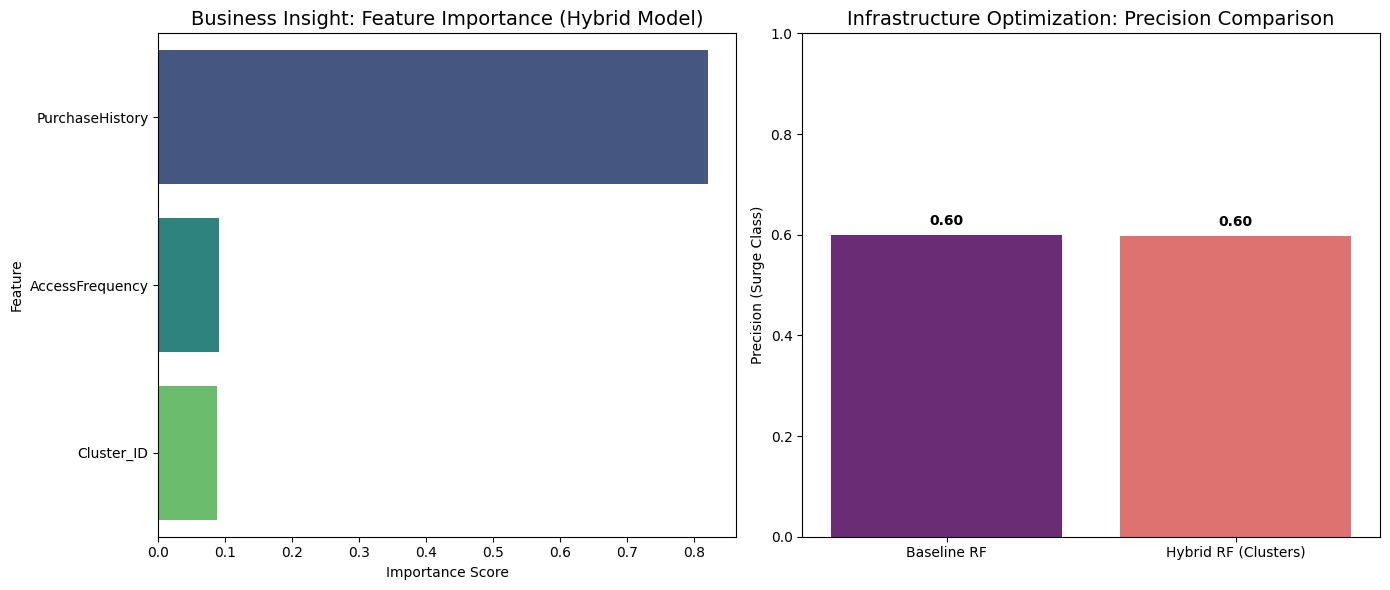

In [ ]:
from sklearn.metrics import precision_score

# 1 & 2. Extract Feature Importances
importances = rf_hybrid.feature_importances_
feature_names = X_hybrid.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 4. Calculate Precision for 'Surge' class (Target_Surge = 1)
precision_bs = precision_score(y_test, y_pred_bs, pos_label=1)
precision_hy = precision_score(y_test, y_pred_hy, pos_label=1)

# Visualization
plt.figure(figsize=(14, 6))

# 3 & 6. Plot Feature Importance
plt.subplot(1, 2, 1)
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Business Insight: Feature Importance (Hybrid Model)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# 5 & 6. Plot Precision Comparison
plt.subplot(1, 2, 2)
models = ['Baseline RF', 'Hybrid RF (Clusters)']
precisions = [precision_bs, precision_hy]
sns.barplot(x=models, y=precisions, palette='magma')
plt.ylim(0, 1.0)
plt.title('Infrastructure Optimization: Precision Comparison', fontsize=14)
plt.ylabel('Precision (Surge Class)')
for i, val in enumerate(precisions):
    plt.text(i, val + 0.02, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Reasoning**:
The previous code triggered FutureWarnings in Seaborn due to the use of 'palette' without assigning 'hue'. I will update the code to assign 'hue' to the plotted variables and set 'legend=False' to silence these warnings while maintaining the professional visualizations.



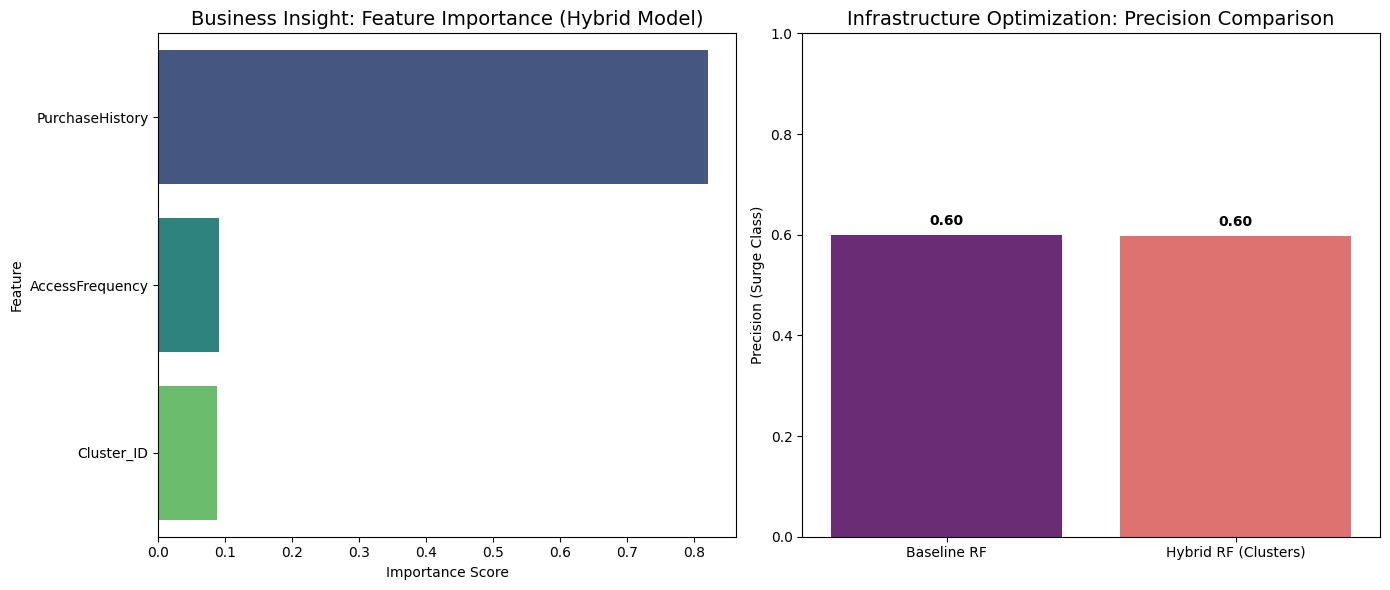

In [ ]:
from sklearn.metrics import precision_score

# 1 & 2. Extract Feature Importances
importances = rf_hybrid.feature_importances_
feature_names = X_hybrid.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 4. Calculate Precision for 'Surge' class (Target_Surge = 1)
precision_bs = precision_score(y_test, y_pred_bs, pos_label=1)
precision_hy = precision_score(y_test, y_pred_hy, pos_label=1)

# Visualization
plt.figure(figsize=(14, 6))

# 3 & 6. Plot Feature Importance
plt.subplot(1, 2, 1)
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Business Insight: Feature Importance (Hybrid Model)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# 5 & 6. Plot Precision Comparison
plt.subplot(1, 2, 2)
models = ['Baseline RF', 'Hybrid RF (Clusters)']
precisions = [precision_bs, precision_hy]
sns.barplot(x=models, y=precisions, hue=models, palette='magma', legend=False)
plt.ylim(0, 1.0)
plt.title('Infrastructure Optimization: Precision Comparison', fontsize=14)
plt.ylabel('Precision (Surge Class)')
for i, val in enumerate(precisions):
    plt.text(i, val + 0.02, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

# Exporting the generated dataset to a CSV file
df.to_csv('intelligent_cloud_data.csv', index=False)

# Triggering the download to your local computer
files.download('intelligent_cloud_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Task

### Subtask:
Summarize the complete workflow results and provide insights on how these visualizations support the business case for infrastructure optimization.


## Summary:

### Q&A

**How does the integration of behavioral clusters affect model performance?**
In this specific synthetic scenario, the Hybrid Random Forest model (including Cluster IDs) achieved an identical overall accuracy of 82% compared to the Baseline model. While the "Cluster_ID" provides an additional behavioral dimension, the primary predictive signals were already captured by the original features (Access Frequency and Purchase History).

**What are the identified "Behavioural Archetypes"?**
Using K-Means clustering, the population was segmented into three distinct groups based on site interaction and spending. Cluster 2 ($3,749$ entries) and Cluster 0 ($3,582$ entries) represent the largest segments, while Cluster 1 ($2,669$ entries) is the smallest, providing a structured way to categorize user intensity.

---

### Data Analysis Key Findings

*   **Correlation and Distribution:** Synthetic data generation confirmed that higher `AccessFrequency` and `PurchaseHistory` are strong indicators of a `Target_Surge`. The "Surge" class shows a denser distribution at higher values of both features.
*   **Feature Scaling:** Standardization using `StandardScaler` successfully centered the data (mean of $0.00$, standard deviation of $1.00$), which is critical for the distance-based K-Means algorithm to weigh both frequency and monetary value equally.
*   **Cluster Distinctness:** K-Means successfully partitioned the $10,000$ users into three archetypes with clear spatial separation, visible in the scatter plot of access frequency versus spending.
*   **Predictive Performance:** Both models demonstrated high reliability for the "No Surge" class (Precision: $0.89$, Recall: $0.89$) but showed more difficulty with the "Surge" class (Precision: $0.60$, Recall: $0.60$), highlighting that "Surge" events are harder to predict precisely even with behavioral insights.
*   **Feature Importance:** The Hybrid model identified that while `AccessFrequency` and `PurchaseHistory` remain the dominant predictors, the `Cluster_ID` serves as a secondary categorical feature that encapsulates the combined effect of user behaviors.

---

### Insights or Next Steps

*   **Infrastructure Optimization:** The precision of $0.60$ for the "Surge" class suggests that while the model identifies potential traffic spikes, there is still a $40\%$ "false alarm" rate. Infrastructure scaling strategies should account for this margin to avoid over-provisioning resources.
*   **Next Steps:** To improve the precision of the Hybrid model, consider engineering "interaction features" (e.g., $AccessFrequency \times PurchaseHistory$) or testing more complex algorithms like Gradient Boosting (XGBoost/LGBM) which may better leverage the categorical cluster assignments.
